In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder


K = 1 Accuracy = 0.7232854864433812
K = 3 Accuracy = 0.7161084529505582
K = 5 Accuracy = 0.7216905901116427
K = 7 Accuracy = 0.7121212121212122
K = 9 Accuracy = 0.715311004784689
confusion_matrix
 [[587 156]
 [201 310]]


Text(50.722222222222214, 0.5, 'Actual')

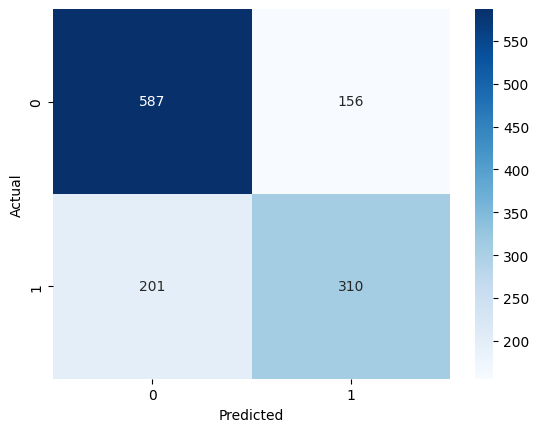

In [49]:
#Knn 

df = pd.read_csv("skoda (1).csv")

mean_price = df["price"].mean()
df["HighPriceCat"] = (df["price"] > mean_price).astype(int)

X = df.drop(columns=["price", "HighPriceCat"])
y = df["HighPriceCat"]

X = X.select_dtypes(include=["number"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

k_values = [1, 3, 5, 7, 9]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("K =", k, "Accuracy =", accuracy)

print("confusion_matrix\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")


In [30]:
# Mulitple linear regresssion

x = df[["mileage","mpg"]]
y = df["price"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train,  y_train)
y_pred = model.predict(x_test)

print(y_pred)


[15994.23837256 13025.95894028 14545.94654304 ... 17730.45416161
 13127.48104884 16135.99188457]


In [ ]:
df2 = pd.read_csv("student_performance.csv")
df2["Age"] = df2["Age"].fillna(df2["Age"].mean())
df2["Study_Hours"] = df2["Study_Hours"].fillna(df2["Study_Hours"].mean())
df2.head()

x = df2[["Test_Score"]]
y = df2["Extra_Classes"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(x_train, y_train)


y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

   Student_ID  Gender  Age  Study_Hours  Attendance (%)  Test_Score  \
0           1    Male   17         5.80            61.3          72   
1           2  Female   16         4.90            85.5          40   
2           3    Male   17         3.38            72.6          58   
3           4    Male   18         5.50            80.3          41   
4           5    Male   17         4.00            96.3          92   

  Parental_Education Internet_Access Extra_Classes  
0       Postgraduate              No            No  
1           Graduate             Yes           Yes  
2        High School              No            No  
3       Postgraduate              No           Yes  
4        High School              No            No  
Accuracy: 0.7
Confusion Matrix:
[[3 2]
 [1 4]]
Classification Report:
              precision    recall  f1-score   support

          No       0.75      0.60      0.67         5
         Yes       0.67      0.80      0.73         5

    accuracy         